# Laboratory #4: Adversarial Learning and OOD Detection

I modelli di Deep Learning possono raggiungere elevate prestazioni sui dati appartenenti alla stessa distribuzione di quelli utilizzati durante l'addestramento, ma il loro comportamento può diventare poco affidabile quando ricevono input diversi da quelli osservati in fase di training o appositamente modificati per indurli in errore.

In questo laboratorio vengono analizzati due aspetti legati alla robustezza dei modelli di classificazione. Il primo riguarda la Out-of-Distribution (OOD) Detection, ovvero la capacità di riconoscere campioni che non appartengono alla distribuzione dei dati di training (In-Distribution, ID), associando a ciascun input uno score che permetta di distinguerne la provenienza. Verranno inoltre utilizzate opportune metriche per valutare quantitativamente la qualità di tale distinzione.

Il secondo aspetto riguarda gli adversarial examples, ottenuti introducendo negli input piccole perturbazioni costruite intenzionalmente per modificare la predizione del modello. Dopo aver valutato la vulnerabilità del classificatore a questo tipo di attacchi, verrà utilizzato l'adversarial training, incorporando esempi adversarial durante l'addestramento con l'obiettivo di aumentare la robustezza del modello.

---
## Exercise 1: OOD Detection and Performance Evaluation

### Exercise 1.1: Build a simple OOD detection pipeline

In questo esercizio verrà implementata una pipeline per la Out-of-Distribution (OOD) Detection, con l’obiettivo di distinguere campioni appartenenti alla distribuzione dei dati di training da campioni provenienti da una distribuzione differente. A questo scopo, è stato scelto CIFAR-10 come dataset In-Distribution (ID) e un sottoinsieme di CIFAR-100 come dataset Out-of-Distribution (OOD), contenente classi non presenti in CIFAR-10. A ciascun campione verrà associato uno score OOD, che quantifica quanto il modello lo consideri estraneo alla distribuzione di training. In questa prima fase, la capacità di separare dati ID e OOD verrà valutata qualitativamente confrontando tramite istogrammi le distribuzioni dei rispettivi score.

Si importano inizialmente le librerie necessarie allo svolgimento del laboratorio:

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import copy
import numpy as np
from sklearn.metrics import (
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from google.colab import drive
drive.mount('/content/drive')
data_path = "/content/drive/MyDrive/DLA_data"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Mounted at /content/drive


Procediamo con il caricamento e la preparazione dei dati. Prima del caricamento viene applicata la trasformazione ToTensor(), che converte ciascuna immagine dal formato PIL in un tensore PyTorch di dimensione \[3,32,32]\, dove i tre canali corrispondono alle componenti RGB e 32 X 32 rappresentano le dimensioni spaziali dell’immagine. Inoltre, i valori dei pixel vengono convertiti dall’intervallo [0,255] all’intervallo [0,1]. Il dataset viene poi suddiviso in training set 80% e validation set 20%, fissando il seed per rendere la suddivisione riproducibile.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor()
])

#Load the ID dataset
cifar10 = datasets.CIFAR10(
    root= data_path,
    train=True,
    download=True,
    transform=transform
)

#Split the dataset into training and validation sets
train_size = int(0.8 * len(cifar10))
val_size = len(cifar10) - train_size

val_size = len(cifar10) - train_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(
    cifar10,
    [train_size, val_size],
    generator = generator
)

print(cifar10.classes)

#Load the OOD dataset
cifar100 = datasets.CIFAR100(
    root= data_path,
    train=False,
    download=True,
    transform=transform
)
print(cifar100.classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', '

Dal dataset CIFAR-100 viene selezionato un sottoinsieme di classi non presenti in CIFAR-10, in modo da ottenere un insieme di campioni effettivamente Out-of-Distribution rispetto ai dati utilizzati per l’addestramento. Vengono quindi individuate le immagini appartenenti alle classi selezionate e raccolte nel dataset OOD tramite Subset.

In [3]:
ood_classes = [
    "apple",
    "bottle",
    "bowl",
    "clock",
    "keyboard",
    "lamp",
    "plate",
    "telephone",
    "television",
    "wardrobe"
]

ood_class_labels = []

for class_name in ood_classes:
    index = cifar100.classes.index(class_name)
    ood_class_labels.append(index)

ood_indices = []

for i, label in enumerate(cifar100.targets):
    if label in ood_class_labels:
        ood_indices.append(i)

ood_dataset = Subset(cifar100, ood_indices)

print("OOD samples:", len(ood_dataset))

OOD samples: 1000


In [4]:
#Create DataLoaders
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

ood_loader = DataLoader(
    ood_dataset,
    batch_size=batch_size,
    shuffle=False
)

Per la classificazione viene utilizzata una ResNet18, inizializzata senza pesi pre-addestrati (weights=None) e quindi addestrata da zero sui dati ID. Poiché l’architettura originale è progettata per immagini di dimensioni maggiori rispetto alle 32 X 32 di CIFAR-10, il primo strato convoluzionale viene modificato utilizzando un kernel 3 X 3, stride 1 e padding 1, e il maxpool iniziale viene rimosso, evitando una riduzione troppo rapida della risoluzione spaziale. Infine, il layer fully-connected viene adattato per produrre 10 output, uno per ciascuna classe di CIFAR-10.

In [5]:
# Define and create the model
def create_model():

    model = models.resnet18(weights=None)

    model.conv1 = nn.Conv2d(
        in_channels=3,
        out_channels=64,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False
    )

    model.maxpool = nn.Identity()

    model.fc = nn.Linear(
        model.fc.in_features,
        10
    )

    return model.to(device)


model = create_model()

print(model)

#Check the model output shape on a training batch
images, labels = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)

print(outputs.shape)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

Procediamo adesso con l'addestramento del modello sui dati di training. Il modello viene addestrato utilizzando la Cross-Entropy Loss, adatta a un problema di classificazione multiclasse, e l’ottimizzatore Adam con learning rate pari a 0.001. Il numero massimo di epoche viene fissato a 30, monitorando a ogni epoca sia la loss sul training set sia la loss e l’accuracy sul validation set.

Per limitare l’overfitting viene utilizzato un criterio di early stopping con patience = 5: se la validation loss non migliora per cinque epoche consecutive, l’addestramento viene interrotto. Durante il training vengono inoltre salvati i pesi corrispondenti alla minima validation loss, che vengono ripristinati al termine dell’addestramento. In questo modo, il modello utilizzato nelle analisi successive non corrisponde necessariamente all’ultima epoca eseguita, ma a quella che ha ottenuto la migliore performance secondo il criterio scelto sul validation set.

In [6]:
#Training setup
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

num_epochs = 30
patience = 5

best_val_loss = float("inf")
best_model_weights = copy.deepcopy(model.state_dict())

epochs_without_improvement = 0

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):

    #Training
    model.train()

    running_train_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    average_train_loss = running_train_loss / len(train_loader)

    train_losses.append(average_train_loss)

    #Validation
    model.eval()

    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()

            total += labels.size(0)


    average_val_loss = running_val_loss / len(val_loader)

    val_accuracy = correct / total

    val_losses.append(average_val_loss)
    val_accuracies.append(val_accuracy)


    #Early stopping
    if average_val_loss < best_val_loss:

        best_val_loss = average_val_loss

        best_model_weights = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {average_train_loss:.4f} | "
        f"Val Loss: {average_val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )


    if epochs_without_improvement >= patience:

        print("Early stopping")

        break


#Load best model
model.load_state_dict(best_model_weights)

Epoch 1/30 | Train Loss: 1.2945 | Val Loss: 1.3656 | Val Accuracy: 0.5359
Epoch 2/30 | Train Loss: 0.8068 | Val Loss: 0.7709 | Val Accuracy: 0.7280
Epoch 3/30 | Train Loss: 0.6103 | Val Loss: 0.6371 | Val Accuracy: 0.7737
Epoch 4/30 | Train Loss: 0.4714 | Val Loss: 0.6048 | Val Accuracy: 0.7937
Epoch 5/30 | Train Loss: 0.3635 | Val Loss: 0.5698 | Val Accuracy: 0.8102
Epoch 6/30 | Train Loss: 0.2739 | Val Loss: 0.6032 | Val Accuracy: 0.8089
Epoch 7/30 | Train Loss: 0.1982 | Val Loss: 0.6238 | Val Accuracy: 0.8201
Epoch 8/30 | Train Loss: 0.1384 | Val Loss: 0.8344 | Val Accuracy: 0.7853
Epoch 9/30 | Train Loss: 0.1063 | Val Loss: 0.7205 | Val Accuracy: 0.8173
Epoch 10/30 | Train Loss: 0.0846 | Val Loss: 0.7463 | Val Accuracy: 0.8155
Early stopping


<All keys matched successfully>

Una volta addestrato il modello, si procede con la OOD detection, associando a ciascun campione uno score che rappresenti quanto esso possa essere considerato Out-of-Distribution. Come OOD score viene utilizzato il complemento della massima probabilità predetta dal modello:

$$ s_{\text{OOD}}(x)=1-\max_k p(y=k\mid x). $$

L’idea è che il modello tenda ad assegnare una probabilità elevata a una delle classi quando riconosce con sicurezza un campione ID, producendo quindi uno score OOD basso. Al contrario, una minore confidenza nella predizione determina uno score OOD più elevato. Lo score viene calcolato sia sui campioni ID del validation set di CIFAR-10 sia sui campioni OOD selezionati da CIFAR-100, in modo da poterne successivamente confrontare le distribuzioni.

In [10]:
#OOD score computation
def get_ood_scores(model, loader):

    scores = []

    model.eval()

    with torch.no_grad():

        for images, _ in loader:

            images = images.to(device)

            outputs = model(images)

            probabilities = torch.softmax(outputs, dim=1)

            max_probabilities = probabilities.max(dim=1).values

            ood_scores = 1 - max_probabilities

            scores.extend(ood_scores.cpu().numpy())

    return scores

id_scores = get_ood_scores(model, val_loader)
ood_scores = get_ood_scores(model, ood_loader)

print("Numero ID scores:", len(id_scores))
print("Numero OOD scores:", len(ood_scores))

Numero ID scores: 10000
Numero OOD scores: 1000


Per effettuare una prima valutazione qualitativa della capacità del modello di distinguere i campioni ID da quelli OOD, vengono confrontate tramite istogrammi le distribuzioni degli OOD score ottenuti sui due dataset. Una buona capacità di separazione dovrebbe produrre score tendenzialmente più bassi per i campioni ID e più elevati per i campioni OOD, con una sovrapposizione limitata tra le due distribuzioni.

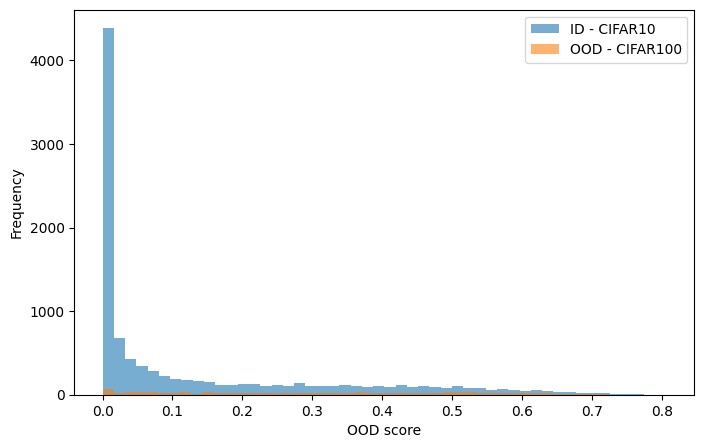

In [11]:
#Results visualization
plt.figure(figsize=(8, 5))

plt.hist(
    id_scores,
    bins=50,
    alpha=0.6,
    label="ID - CIFAR10"
)

plt.hist(
    ood_scores,
    bins=50,
    alpha=0.6,
    label="OOD - CIFAR100"
)

plt.xlabel("OOD score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

Dalla distribuzione degli OOD score si osserva che i campioni ID tendono a concentrarsi maggiormente verso valori bassi, indicando un’elevata confidenza del modello sulle immagini appartenenti alla distribuzione di training. I campioni OOD presentano invece una distribuzione più dispersa, ma rimane una significativa sovrapposizione tra le due distribuzioni. Questo indica che lo score basato sulla massima probabilità predetta consente una separazione parziale tra campioni ID e OOD, ma il modello può comunque assegnare un’elevata confidenza anche ad alcuni campioni provenienti da una distribuzione differente. Sarà quindi necessario valutare quantitativamente la capacità di separazione attraverso le metriche introdotte nell’esercizio successivo.

### Exercise 1.2: Measure your OOD detection performance

Dopo la valutazione qualitativa tramite istogrammi, si procede con una valutazione quantitativa delle prestazioni del detector OOD. In particolare, vengono utilizzate metriche threshold-free, che permettono di valutare la capacità di separare campioni ID e OOD senza fissare una specifica soglia sullo score. Verranno considerate la ROC curve per la classificazione ID e le Precision-Recall curve sia per ID sia per OOD, come richiesto dall’esercizio.

Per valutare quantitativamente la capacità del detector di riconoscere i campioni ID, vengono costruite delle label binarie, assegnando valore 1 ai campioni ID e 0 ai campioni OOD. Poiché lo score precedentemente definito aumenta all’aumentare della probabilità che un campione sia OOD, viene inoltre definito il corrispondente ID score come \(s_{\mathrm{ID}}=1-s_{\mathrm{OOD}}\), in modo che valori più elevati indichino una maggiore probabilità di appartenenza alla distribuzione ID

In [12]:
id_scores = np.array(id_scores)
ood_scores = np.array(ood_scores)

#Prepare labels and scores for ID detection
true_labels_id = np.concatenate([
    np.ones(len(id_scores)),
    np.zeros(len(ood_scores))
])

all_id_scores = np.concatenate([
    1 - id_scores,
    1 - ood_scores
])

#Prepare labels and scores for OOD detection
true_labels_ood = np.concatenate([
    np.zeros(len(id_scores)),
    np.ones(len(ood_scores))
])

all_ood_scores = np.concatenate([
    id_scores,
    ood_scores
])

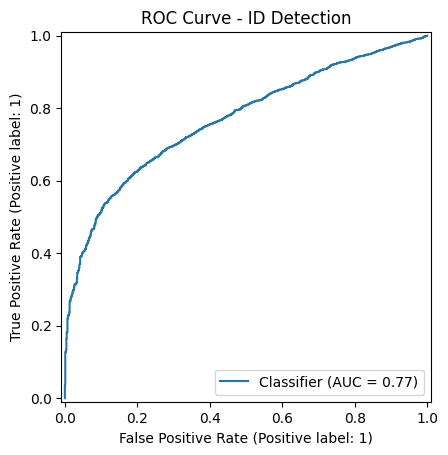

In [13]:
#ROC curve for ID detection
RocCurveDisplay.from_predictions(
    true_labels_id,
    all_id_scores
)

plt.title("ROC Curve - ID Detection")
plt.show()

La ROC curve rappresenta il compromesso tra il True Positive Rate (TPR), ovvero la frazione di campioni ID correttamente riconosciuti come tali, e il False Positive Rate (FPR), ovvero la frazione di campioni OOD erroneamente classificati come ID, al variare della soglia applicata all’ID score. L’area sotto la curva (AUROC) misura complessivamente la capacità del detector di separare le due distribuzioni: un valore pari a 0.5 corrisponde a una separazione casuale, mentre un valore pari a 1 indica una separazione perfetta. In questa esecuzione si ottiene un AUROC pari a 0.77, che indica una capacità di discriminazione moderata tra campioni ID e OOD, coerentemente con la parziale sovrapposizione delle distribuzioni degli OOD score osservata precedentemente.

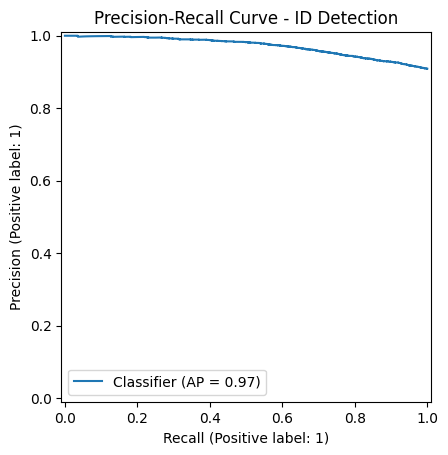

In [14]:
#Precision-Recall curve for ID detection
PrecisionRecallDisplay.from_predictions(
    true_labels_id,
    all_id_scores
)

plt.title("Precision-Recall Curve - ID Detection")
plt.show()

La Precision-Recall curve valuta la capacità del detector di identificare i campioni ID, considerati in questo caso come classe positiva. La recall rappresenta la frazione di campioni ID correttamente identificati rispetto al totale dei campioni ID, mentre la precision indica la frazione di campioni effettivamente ID tra tutti quelli classificati come tali. Idealmente, entrambe dovrebbero mantenersi vicine a 1.

In questa esecuzione si ottiene un'Average Precision (AP) pari a 0.97. Il valore elevato deve tuttavia essere interpretato considerando lo sbilanciamento tra le due classi, poiché i campioni ID sono significativamente più numerosi dei campioni OOD. Per questo motivo è importante considerare anche la Precision-Recall curve ottenuta assumendo i campioni OOD come classe positiva, analizzata successivamente.

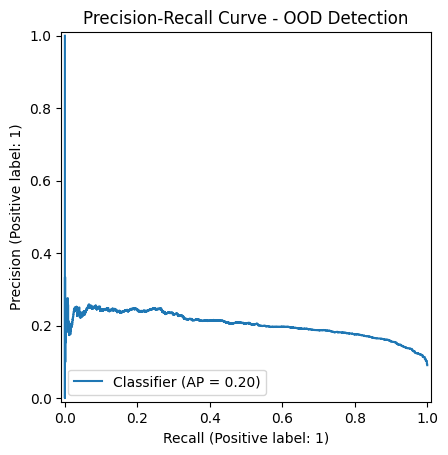

In [15]:
#Precision-Recall curve for OOD detection
PrecisionRecallDisplay.from_predictions(
    true_labels_ood,
    all_ood_scores
)

plt.title("Precision-Recall Curve - OOD Detection")
plt.show()

In questo caso i campioni OOD sono considerati come classe positiva. La Precision-Recall curve mostra una diminuzione della precision all'aumentare della recall: identificando una frazione sempre maggiore dei campioni OOD, aumenta anche il numero di campioni ID erroneamente identificati come OOD. In questa esecuzione si ottiene un'Average Precision (AP) pari a 0.20, indicando una capacità limitata del detector di identificare correttamente i campioni OOD. Questo risultato è coerente con la sovrapposizione osservata precedentemente tra le distribuzioni degli OOD score e conferma che la semplice confidenza massima del classificatore non consente una separazione netta tra dati ID e OOD.
Si sottolinea inoltre che la forte differenza rispetto all'AP ottenuta considerando gli ID come classe positiva è inoltre influenzata dallo sbilanciamento numerico tra campioni ID e OOD, a cui la Precision-Recall curve è particolarmente sensibile.

---
## Exercise 2: Enhancing Robustness to Adversarial Attack

### Exercise 2.1: Implement FGSM and generate adversarial examples

In questo esercizio viene analizzata la vulnerabilità del modello agli adversarial examples, ovvero campioni ottenuti introducendo piccole perturbazioni intenzionali negli input con l'obiettivo di modificare la predizione del classificatore. Le perturbazioni vengono generate utilizzando il Fast Gradient Sign Method (FGSM).

FGSM utilizza il gradiente della loss rispetto all'immagine di input x per individuare la direzione in cui modificare i pixel in modo da aumentare la loss del modello. La perturbazione è definita come:

$$ \eta(x)=\epsilon\,\mathrm{sign}\left(\nabla_x L(\theta,x,y)\right) $$

e l'immagine adversarial viene quindi ottenuta come:

$$ x_{\mathrm{adv}}=x+\eta(x). $$

Il parametro ɛ controlla l'intensità della perturbazione: valori piccoli producono modifiche limitate dell'immagine, mentre valori maggiori rendono l'attacco più forte. Gli adversarial examples generati verranno valutati qualitativamente, confrontando le immagini originali e perturbate, e quantitativamente, misurando la variazione dell'accuracy del modello per diversi valori di ɛ.

Di seguito si implementa quindi la funzione utilizzata per generare gli adversarial examples tramite FGSM.

In [16]:
#FGSM Implementation
def fgsm_attack(image, epsilon, gradient):

    perturbation = epsilon * gradient.sign()

    adversarial_image = image + perturbation

    adversarial_image = torch.clamp(
        adversarial_image,
        0,
        1
    )

    return adversarial_image

Si procede quindi con la generazione degli adversarial examples a partire da un batch di immagini del validation set. Per ciascuna immagine viene calcolato il gradiente della loss rispetto all'input, utilizzato successivamente da FGSM per determinare la direzione della perturbazione. In questa prima analisi viene scelto ɛ = 0.03; l'effetto di diversi valori di ɛ verrà analizzato successivamente.

In [17]:
#Adversarial examples generation
model.eval()

images, labels = next(iter(val_loader))

images = images.to(device)
labels = labels.to(device)

images.requires_grad = True

outputs = model(images)

loss = criterion(outputs, labels)

model.zero_grad()

loss.backward()

image_gradients = images.grad.data

epsilon = 0.03

adversarial_images = fgsm_attack(
    images,
    epsilon,
    image_gradients
)

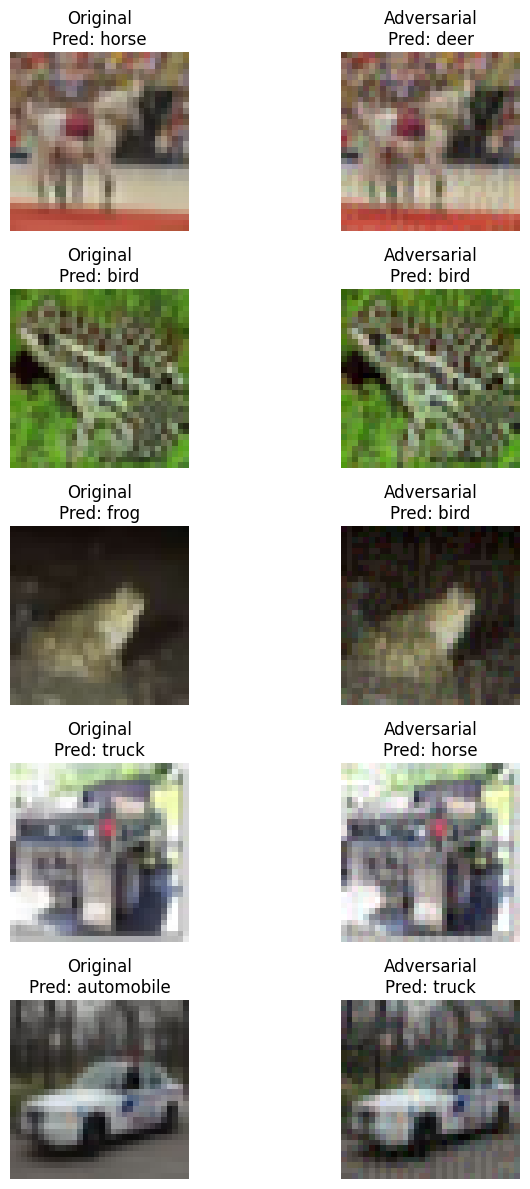

In [18]:
#Compute predictions for original and adversarial images
with torch.no_grad():

    original_outputs = model(images)
    adversarial_outputs = model(adversarial_images)

    original_predictions = original_outputs.argmax(dim=1)
    adversarial_predictions = adversarial_outputs.argmax(dim=1)

#Compare original and adversarial images
num_images = 5

fig, axes = plt.subplots(num_images, 2, figsize=(8, 12))

for i in range(num_images):

    original_image = images[i].detach().cpu()
    adversarial_image = adversarial_images[i].detach().cpu()

    original_image = original_image.permute(1, 2, 0)
    adversarial_image = adversarial_image.permute(1, 2, 0)

    axes[i, 0].imshow(original_image)
    axes[i, 0].set_title(
        f"Original\nPred: {cifar10.classes[original_predictions[i].item()]}"
    )
    axes[i, 0].axis("off")

    axes[i, 1].imshow(adversarial_image)
    axes[i, 1].set_title(
        f"Adversarial\nPred: {cifar10.classes[adversarial_predictions[i].item()]}"
    )
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

Sopra sono riportati alcuni esempi di immagini originali e delle corrispondenti immagini adversarial generate tramite FGSM con ɛ =0.03. Le immagini adversarial risultano visivamente molto simili alle originali, nonostante in diversi casi la perturbazione sia sufficiente a modificare la predizione del modello. Questo evidenzia come variazioni di intensità limitata dell'input possano compromettere il comportamento del classificatore senza produrre alterazioni visive particolarmente evidenti.

Dopo la valutazione qualitativa, si procede con una valutazione quantitativa della vulnerabilità del modello all'attacco FGSM. Viene definita una funzione che genera adversarial examples sull'intero validation set e calcola l'accuracy del modello sulle immagini perturbate per un determinato valore di ɛ. Ripetendo successivamente la valutazione per diversi valori di ɛ, è possibile analizzare come l'intensità della perturbazione influenzi le prestazioni del classificatore.

In [19]:
#FGSM robustness evaluation
def evaluate_fgsm(model, loader, epsilon):

    model.eval()

    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        images.requires_grad = True

        outputs = model(images)

        loss = criterion(outputs, labels)

        model.zero_grad()

        loss.backward()

        image_gradients = images.grad.data

        adversarial_images = fgsm_attack(
            images,
            epsilon,
            image_gradients
        )

        with torch.no_grad():

            adversarial_outputs = model(adversarial_images)

            predictions = adversarial_outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()

            total += labels.size(0)

    accuracy = correct / total

    return accuracy

Epsilon: 0.00 | Accuracy: 0.8102
Epsilon: 0.01 | Accuracy: 0.1795
Epsilon: 0.03 | Accuracy: 0.0191
Epsilon: 0.05 | Accuracy: 0.0113
Epsilon: 0.10 | Accuracy: 0.0197


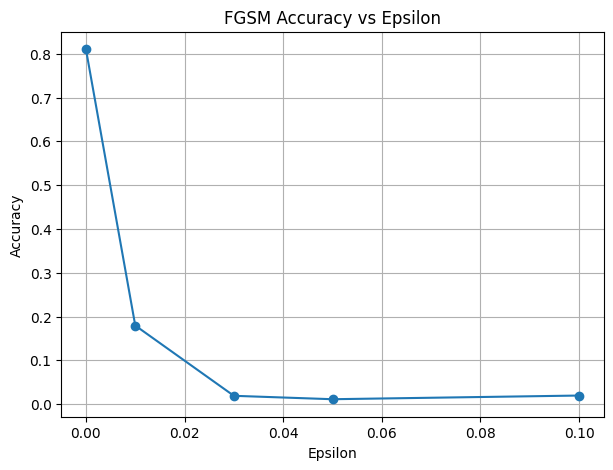

In [20]:
#Evaluation for different epsilon values
epsilons = [0.0, 0.01, 0.03, 0.05, 0.1]

accuracies = []

for epsilon in epsilons:

    accuracy = evaluate_fgsm(
        model,
        val_loader,
        epsilon
    )

    accuracies.append(accuracy)

    print(
        f"Epsilon: {epsilon:.2f} | "
        f"Accuracy: {accuracy:.4f}"
    )

#Plot accuracy as a function of epsilon
plt.figure(figsize=(7, 5))
plt.plot(epsilons, accuracies, marker="o")

plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.title("FGSM Accuracy vs Epsilon")
plt.grid()

plt.show()

Il grafico mostra una forte dipendenza dell'accuracy dal valore di ɛ. In assenza di perturbazione, il modello mantiene un'accuracy di circa 0.81, coerente con le prestazioni ottenute sul validation set. Tuttavia, già per ɛ = 0.01 l'accuracy scende a circa 0.17, mostrando che una perturbazione di intensità molto ridotta è sufficiente a compromettere significativamente le predizioni del modello.
Aumentando ulteriormente ɛ, l'accuracy diminuisce fino a valori prossimi allo zero, indicando che FGSM riesce a generare adversarial examples altamente efficaci. Il risultato evidenzia quindi una forte vulnerabilità del modello agli attacchi adversarial.

### Exercise 2.2: Augment training with adversarial examples
In questo esercizio viene utilizzato FGSM non più soltanto per attaccare il modello, ma anche per rendere l’addestramento più robusto. Durante il training vengono infatti generate immagini adversarial a partire dai campioni ID e utilizzando il modello nello stato corrente, in modo che le perturbazioni riflettano continuamente le vulnerabilità apprese durante l’addestramento.

Le immagini originali e le corrispondenti immagini adversarial vengono quindi utilizzate insieme per aggiornare i pesi del modello. Questo approccio prende il nome di adversarial training e ha l’obiettivo di ridurre la sensibilità del classificatore a piccole perturbazioni dell’input.

Al termine dell’addestramento, il modello ottenuto verrà confrontato con quello originale per verificare se l’adversarial training ne abbia aumentato la resistenza agli attacchi FGSM. Verrà inoltre ripetuta la pipeline di OOD detection introdotta nell’Esercizio 1, per valutare come l’adversarial training abbia influenzato la capacità del modello di distinguere campioni ID e OOD

In [21]:
# Create a new model for adversarial training
robust_model = create_model()

In [22]:
#Adversarial training setup
robust_criterion = nn.CrossEntropyLoss()

robust_optimizer = torch.optim.Adam(
    robust_model.parameters(),
    lr=0.001
)

num_epochs = 30
patience = 5

epsilon_train = 0.03

best_val_loss = float("inf")

best_robust_weights = copy.deepcopy(
    robust_model.state_dict()
)

epochs_without_improvement = 0

robust_train_losses = []
robust_val_losses = []
robust_val_accuracies = []

for epoch in range(num_epochs):

    #Training
    robust_model.train()
    running_train_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)


        # Generate FGSM examples
        images.requires_grad = True

        outputs = robust_model(images)

        attack_loss = robust_criterion(
            outputs,
            labels
        )

        robust_model.zero_grad()

        attack_loss.backward()

        image_gradients = images.grad.detach()

        adversarial_images = fgsm_attack(
            images.detach(),
            epsilon_train,
            image_gradients
        )

        adversarial_images = adversarial_images.detach()


        #Adversarial batch
        combined_images = torch.cat(
            [images.detach(), adversarial_images],
            dim=0
        )

        combined_labels = torch.cat(
            [labels, labels],
            dim=0
        )


        robust_optimizer.zero_grad()

        outputs = robust_model(combined_images)

        loss = robust_criterion(
            outputs,
            combined_labels
        )

        loss.backward()

        robust_optimizer.step()

        running_train_loss += loss.item()


    average_train_loss = (
        running_train_loss / len(train_loader)
    )

    robust_train_losses.append(
        average_train_loss
    )


    #Validation
    robust_model.eval()

    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = robust_model(images)

            loss = robust_criterion(
                outputs,
                labels
            )

            running_val_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)


    average_val_loss = (
        running_val_loss / len(val_loader)
    )

    val_accuracy = correct / total

    robust_val_losses.append(
        average_val_loss
    )

    robust_val_accuracies.append(
        val_accuracy
    )


    #Early stopping
    if average_val_loss < best_val_loss:

        best_val_loss = average_val_loss

        best_robust_weights = copy.deepcopy(
            robust_model.state_dict()
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {average_train_loss:.4f} | "
        f"Val Loss: {average_val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f}"
    )


    if epochs_without_improvement >= patience:

        print("Early stopping")
        break


#Load best model
robust_model.load_state_dict(
    best_robust_weights
)

Epoch 1/30 | Train Loss: 1.8279 | Val Loss: 1.3852 | Val Accuracy: 0.4975
Epoch 2/30 | Train Loss: 1.5632 | Val Loss: 1.1635 | Val Accuracy: 0.5934
Epoch 3/30 | Train Loss: 1.4057 | Val Loss: 0.9906 | Val Accuracy: 0.6704
Epoch 4/30 | Train Loss: 1.2739 | Val Loss: 0.8940 | Val Accuracy: 0.7029
Epoch 5/30 | Train Loss: 1.1689 | Val Loss: 0.8207 | Val Accuracy: 0.7224
Epoch 6/30 | Train Loss: 1.0712 | Val Loss: 0.7524 | Val Accuracy: 0.7555
Epoch 7/30 | Train Loss: 0.9617 | Val Loss: 0.7027 | Val Accuracy: 0.7610
Epoch 8/30 | Train Loss: 0.8525 | Val Loss: 0.6852 | Val Accuracy: 0.7691
Epoch 9/30 | Train Loss: 0.7244 | Val Loss: 0.6872 | Val Accuracy: 0.7589
Epoch 10/30 | Train Loss: 0.5961 | Val Loss: 0.6749 | Val Accuracy: 0.7703
Epoch 11/30 | Train Loss: 0.4694 | Val Loss: 0.6604 | Val Accuracy: 0.7762
Epoch 12/30 | Train Loss: 0.3779 | Val Loss: 0.7032 | Val Accuracy: 0.7699
Epoch 13/30 | Train Loss: 0.2911 | Val Loss: 0.7148 | Val Accuracy: 0.7657
Epoch 14/30 | Train Loss: 0.2457 |

<All keys matched successfully>

Epsilon: 0.00 | Normal: 0.8102 | Robust: 0.7762
Epsilon: 0.01 | Normal: 0.1795 | Robust: 0.6391
Epsilon: 0.03 | Normal: 0.0191 | Robust: 0.3863
Epsilon: 0.05 | Normal: 0.0113 | Robust: 0.2206
Epsilon: 0.10 | Normal: 0.0197 | Robust: 0.0607


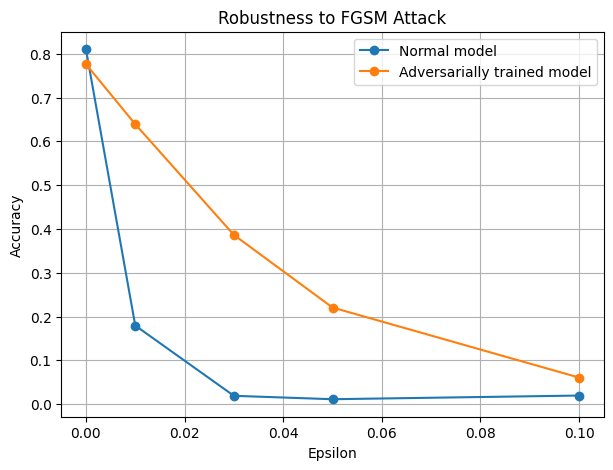

In [23]:
#FGSM robustness comparison
epsilons = [0.0, 0.01, 0.03, 0.05, 0.1]

normal_accuracies = []
robust_accuracies = []

for epsilon in epsilons:

    normal_accuracy = evaluate_fgsm(
        model,
        val_loader,
        epsilon
    )

    robust_accuracy = evaluate_fgsm(
        robust_model,
        val_loader,
        epsilon
    )

    normal_accuracies.append(normal_accuracy)
    robust_accuracies.append(robust_accuracy)

    print(
        f"Epsilon: {epsilon:.2f} | "
        f"Normal: {normal_accuracy:.4f} | "
        f"Robust: {robust_accuracy:.4f}"
    )

#Plot accuracy as a function of epsilon
plt.figure(figsize=(7, 5))

plt.plot(
    epsilons,
    normal_accuracies,
    marker="o",
    label="Normal model"
)

plt.plot(
    epsilons,
    robust_accuracies,
    marker="o",
    label="Adversarially trained model"
)

plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.title("Robustness to FGSM Attack")
plt.legend()
plt.grid()

plt.show()

Il confronto mostra che l’adversarial training aumenta significativamente la robustezza del modello agli attacchi FGSM. In assenza di perturbazione, i due modelli presentano prestazioni molto simili, indicando che l’addestramento adversarial non ha comportato una perdita rilevante di accuracy sui campioni non perturbati. All’aumentare di ɛ, invece, l’accuracy del modello originale diminuisce rapidamente, raggiungendo valori prossimi allo zero già per perturbazioni relativamente piccole. Il modello addestrato adversarialmente mantiene invece un’accuracy sensibilmente maggiore per tutti i valori di ɛ considerati, anche se le sue prestazioni diminuiscono comunque all’aumentare dell’intensità dell’attacco.

Si valuta adesso la capacità di OOD detection del modello ottenuto tramite adversarial training, utilizzando le stesse metriche introdotte nell’Esercizio 1.

In [24]:
#Compute OOD scores
robust_id_scores = get_ood_scores(
    robust_model,
    val_loader
)

robust_ood_scores = get_ood_scores(
    robust_model,
    ood_loader
)

robust_id_scores = np.array(robust_id_scores)
robust_ood_scores = np.array(robust_ood_scores)

#Labels and scores for ID detection
robust_true_labels_id = np.concatenate([
    np.ones(len(robust_id_scores)),
    np.zeros(len(robust_ood_scores))
])

robust_all_id_scores = np.concatenate([
    1 - robust_id_scores,
    1 - robust_ood_scores
])

#Labels and scores for OOD detection
robust_true_labels_ood = np.concatenate([
    np.zeros(len(robust_id_scores)),
    np.ones(len(robust_ood_scores))
])

robust_all_ood_scores = np.concatenate([
    robust_id_scores,
    robust_ood_scores
])

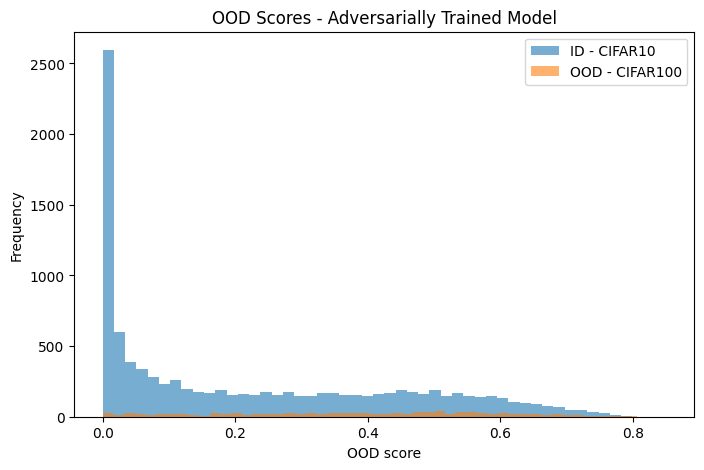

In [25]:
#OOD score distribution
plt.figure(figsize=(8, 5))

plt.hist(
    robust_id_scores,
    bins=50,
    alpha=0.6,
    label="ID - CIFAR10"
)

plt.hist(
    robust_ood_scores,
    bins=50,
    alpha=0.6,
    label="OOD - CIFAR100"
)

plt.xlabel("OOD score")
plt.ylabel("Frequency")
plt.title("OOD Scores - Adversarially Trained Model")
plt.legend()

plt.show()

Come nel caso precedente, l’istogramma mostra che i campioni ID tendono a concentrarsi maggiormente verso valori bassi dell’OOD score, indicando una maggiore confidenza del modello nelle relative predizioni. I campioni OOD risultano invece maggiormente distribuiti verso valori più elevati. Le due distribuzioni presentano tuttavia una significativa sovrapposizione, indicando che la separazione tra campioni ID e OOD rimane parziale.

Per facilitare la lettura e il confronto tra le due distribuzioni, viene riportato anche l’istogramma normalizzato, eliminando l’effetto dovuto alla diversa numerosità dei campioni ID e OOD.

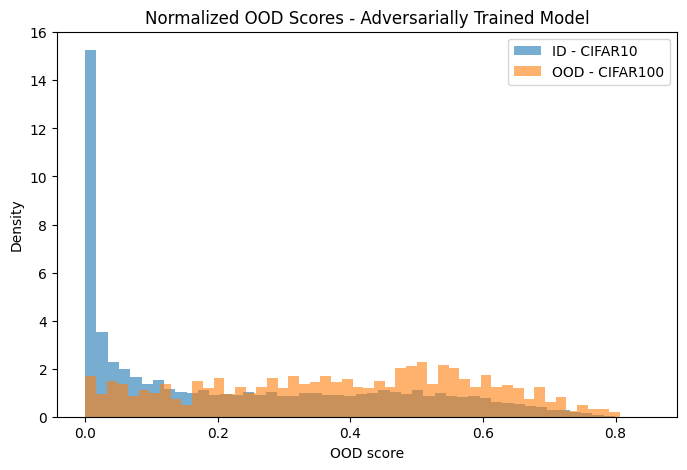

In [26]:
plt.figure(figsize=(8, 5))

plt.hist(
    robust_id_scores,
    bins=50,
    alpha=0.6,
    density=True,
    label="ID - CIFAR10"
)

plt.hist(
    robust_ood_scores,
    bins=50,
    alpha=0.6,
    density=True,
    label="OOD - CIFAR100"
)

plt.xlabel("OOD score")
plt.ylabel("Density")
plt.title("Normalized OOD Scores - Adversarially Trained Model")

plt.legend()
plt.show()

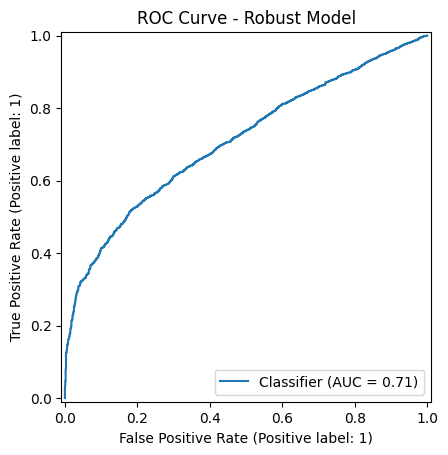

In [27]:
#ROC curve for ID detection
RocCurveDisplay.from_predictions(
    robust_true_labels_id,
    robust_all_id_scores
)

plt.title("ROC Curve - Robust Model")
plt.show()

La curva ROC mostra una capacità moderata del modello di distinguere i campioni ID da quelli OOD. In questa esecuzione si ottiene un valore di AUC pari a 0.71: il risultato è superiore a quello di un classificatore casuale, ma evidenzia che la separazione tra le due distribuzioni non è particolarmente netta.

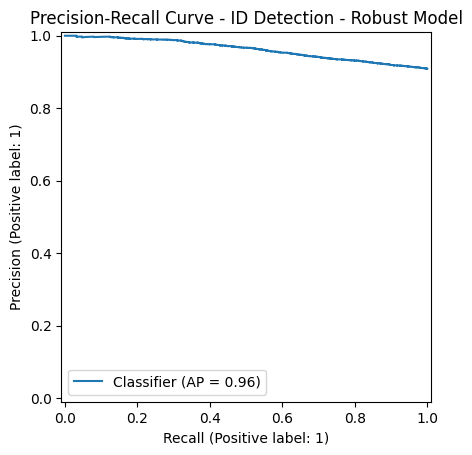

In [28]:
#Precision-Recall curve for ID detection
PrecisionRecallDisplay.from_predictions(
    robust_true_labels_id,
    robust_all_id_scores
)

plt.title("Precision-Recall Curve - ID Detection - Robust Model")
plt.show()

La Precision-Recall curve relativa alla ID detection mostra prestazioni elevate, con un valore di Average Precision pari a 0.96. Il modello riesce quindi a identificare efficacemente i campioni ID. Questo valore deve tuttavia essere interpretato considerando la maggiore numerosità dei campioni ID rispetto a quelli OOD, che rende questa metrica particolarmente favorevole alla classe ID.

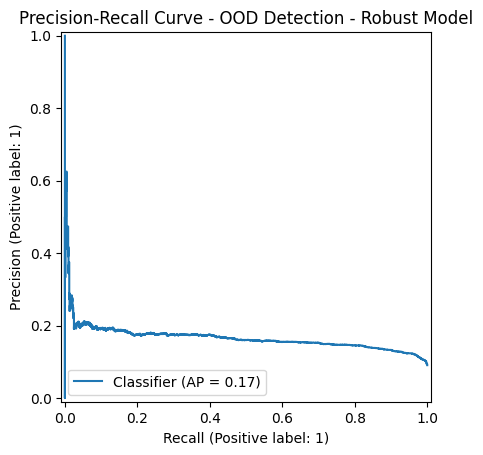

In [29]:
#Precision-Recall curve for OOD detection
PrecisionRecallDisplay.from_predictions(
    robust_true_labels_ood,
    robust_all_ood_scores
)

plt.title("Precision-Recall Curve - OOD Detection - Robust Model")
plt.show()

La Precision-Recall curve relativa alla OOD detection evidenzia invece prestazioni più limitate, con un valore di Average Precision pari a 0.17. Il risultato conferma quanto osservato nell’istogramma degli OOD score: la sovrapposizione tra le distribuzioni ID e OOD rende difficile identificare in modo affidabile i campioni OOD utilizzando esclusivamente la confidenza massima del classificatore.

Per rendere più immediato il confronto quantitativo tra i due modelli, vengono riportati in tabella i valori di accuracy ottenuti per ciascun valore di ɛ.

In [30]:
import pandas as pd
comparison_table = pd.DataFrame({
    "Epsilon": epsilons,
    "Normal Model Accuracy (%)": [
        acc * 100 for acc in normal_accuracies
    ],
    "Robust Model Accuracy (%)": [
        acc * 100 for acc in robust_accuracies
    ]
})

comparison_table = comparison_table.round(2)

comparison_table

,Epsilon,Normal Model Accuracy (%),Robust Model Accuracy (%)
0,0.00,81.02,77.62
1,0.01,17.95,63.91
2,0.03,1.91,38.63
3,0.05,1.13,22.06
4,0.10,1.97,6.07


---
## Exercise 3: Wildcard
### Exercise 3.3: Experiment with *targeted* adversarial attacks
In questo esercizio viene analizzata una variante targeted degli adversarial attacks. A differenza del FGSM utilizzato nell’Esercizio 2.1, il cui obiettivo era semplicemente indurre il modello a effettuare una classificazione errata, un targeted attack cerca di modificare l’immagine in modo che il modello la classifichi come una specifica classe target scelta in precedenza.

In questa analisi è stata scelta come target la classe airplane di CIFAR-10. L’obiettivo dell’attacco sarà quindi quello di perturbare immagini appartenenti alle altre classi in modo da indurre il modello a classificarle come airplane.

Nel targeted FGSM, il gradiente viene calcolato rispetto alla loss associata alla classe target. La perturbazione viene applicata nella direzione che riduce tale loss, aumentando la probabilità che il modello assegni l’immagine alla classe desiderata:

$$ x_{\mathrm{adv}} = x - \epsilon \, \mathrm{sign} \left(\nabla_x L(\theta,x,y_{\mathrm{target}})\right) $$

L’efficacia dell’attacco verrà valutata sia qualitativamente, osservando alcune immagini adversarial e le relative predizioni, sia quantitativamente, misurando la percentuale di campioni che, dopo l’attacco, vengono classificati come appartenenti alla classe target per diversi valori di ɛ.

In [35]:
#Targeted FGSM implementation
def targeted_fgsm_attack(image, epsilon, gradient):

    perturbation = epsilon * gradient.sign()

    adversarial_image = image - perturbation

    adversarial_image = torch.clamp(
        adversarial_image,
        0,
        1
    )

    return adversarial_image

#Targeted adversarial examples generation
model.eval()

images, labels = next(iter(val_loader))

images = images.to(device)
labels = labels.to(device)

target_class = 0

target_labels = torch.full_like(
    labels,
    target_class
)

images.requires_grad = True

outputs = model(images)

target_loss = criterion(
    outputs,
    target_labels
)

model.zero_grad()

target_loss.backward()

image_gradients = images.grad.detach()

epsilon = 0.03

targeted_images = targeted_fgsm_attack(
    images.detach(),
    epsilon,
    image_gradients
)

with torch.no_grad():

    targeted_outputs = model(targeted_images)

    targeted_predictions = targeted_outputs.argmax(dim=1)

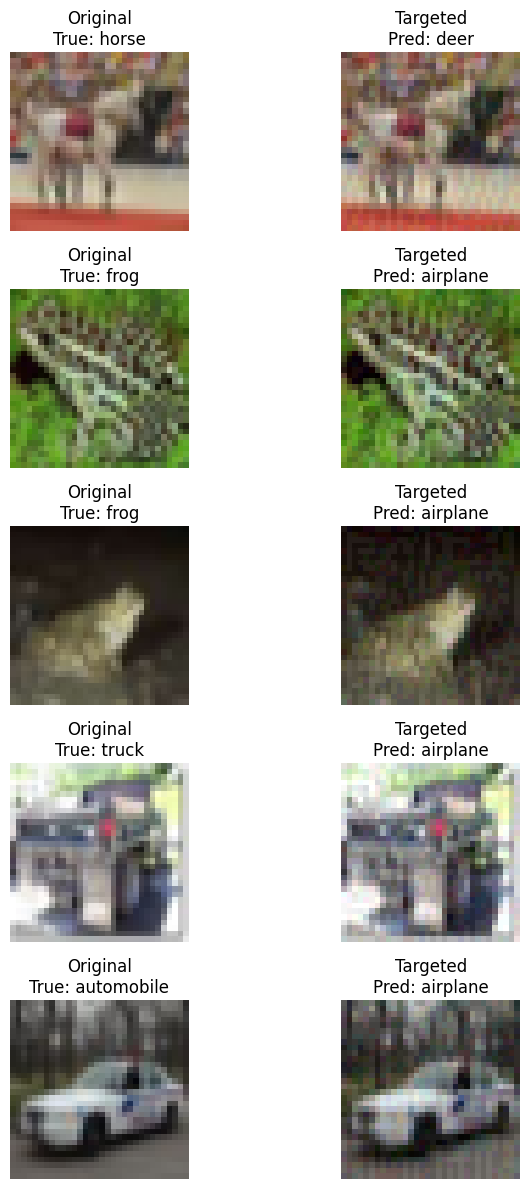

In [36]:
#Qualitative evaluation of targeted FGSM
num_images = 5

fig, axes = plt.subplots(
    num_images,
    2,
    figsize=(8, 12)
)

for i in range(num_images):

    original_image = images[i].detach().cpu().permute(1, 2, 0)

    targeted_image = (
        targeted_images[i]
        .detach()
        .cpu()
        .permute(1, 2, 0)
    )

    axes[i, 0].imshow(original_image)

    axes[i, 0].set_title(
        f"Original\nTrue: {cifar10.classes[labels[i].item()]}"
    )

    axes[i, 0].axis("off")


    axes[i, 1].imshow(targeted_image)

    axes[i, 1].set_title(
        f"Targeted\nPred: {cifar10.classes[targeted_predictions[i].item()]}"
    )

    axes[i, 1].axis("off")


plt.tight_layout()
plt.show()


Di seguito si procede con l’analisi quantitativa dell’efficacia dell’attacco. Nel calcolo vengono esclusi i campioni che appartengono già alla classe target o che vengono già classificati come tali prima dell’attacco, in modo da considerare esclusivamente i cambiamenti di predizione effettivamente prodotti dall’attacco.

Epsilon: 0.00 | Success rate: 0.00%
Epsilon: 0.01 | Success rate: 33.87%
Epsilon: 0.03 | Success rate: 62.90%
Epsilon: 0.05 | Success rate: 64.52%
Epsilon: 0.10 | Success rate: 61.29%


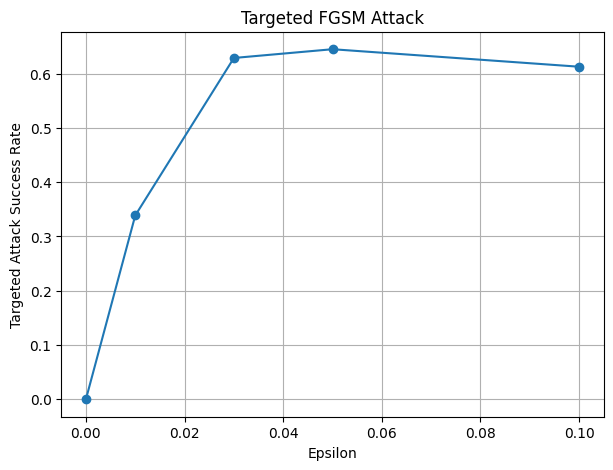

In [38]:
#Quantitative evaluation of targeted FGSM
epsilons = [0.0, 0.01, 0.03, 0.05, 0.1]

targeted_success_rates = []

for epsilon in epsilons:

    images, labels = next(iter(val_loader))

    images = images.to(device)
    labels = labels.to(device)

    target_labels = torch.full_like(
        labels,
        target_class
    )

    images.requires_grad = True

    outputs = model(images)

    original_predictions = outputs.argmax(dim=1)

    target_loss = criterion(
        outputs,
        target_labels
    )

    model.zero_grad()
    target_loss.backward()

    image_gradients = images.grad.detach()

    targeted_images = targeted_fgsm_attack(
        images.detach(),
        epsilon,
        image_gradients
    )

    with torch.no_grad():

        targeted_outputs = model(
            targeted_images
        )

        targeted_predictions = (
            targeted_outputs.argmax(dim=1)
        )

    # Consider only samples that were not already target samples
    # and were not already predicted as the target class
    mask = (
        (labels != target_class)
        &
        (original_predictions != target_class)
    )

    success_rate = (
        targeted_predictions[mask] == target_class
    ).float().mean().item()

    targeted_success_rates.append(
        success_rate
    )

    print(
        f"Epsilon: {epsilon:.2f} | "
        f"Success rate: {success_rate * 100:.2f}%"
    )


plt.figure(figsize=(7, 5))

plt.plot(
    epsilons,
    targeted_success_rates,
    marker="o"
)

plt.xlabel("Epsilon")
plt.ylabel("Targeted Attack Success Rate")
plt.title("Targeted FGSM Attack")
plt.grid()
plt.show()

I risultati mostrano che l’efficacia del targeted FGSM aumenta inizialmente con ɛ, raggiungendo il massimo intorno a ɛ =0.05. Per valori maggiori il success rate diminuisce: essendo FGSM un attacco a singolo passo, il gradiente indica la direzione localmente più favorevole verso la classe target, ma una perturbazione troppo grande può spostare l’immagine oltre la regione in cui tale direzione risulta efficace. Di conseguenza, aumentare ɛ non garantisce necessariamente un attacco targeted più efficace.

 Per questo motivo viene sperimentata anche una variante iterativa dell’attacco, nella quale la perturbazione non viene applicata in un unico passo, ma attraverso una sequenza di piccoli aggiornamenti. A ogni iterazione viene ricalcolato il gradiente della loss rispetto alla classe target, permettendo di aggiornare progressivamente l’immagine nella direzione che favorisce la classificazione desiderata. La perturbazione complessiva viene comunque mantenuta entro il limite definito da ɛ, così da controllare l’entità massima della modifica rispetto all’immagine originale.

In [39]:
#Iterative targeted FGSM implementation

def targeted_iterative_fgsm(
    model,
    images,
    target_labels,
    epsilon,
    alpha,
    num_steps
):
    original_images = images.detach().clone()
    adversarial_images = images.detach().clone()

    for _ in range(num_steps):

        adversarial_images.requires_grad_(True)

        outputs = model(adversarial_images)

        loss = criterion(
            outputs,
            target_labels
        )

        model.zero_grad()
        loss.backward()

        gradients = adversarial_images.grad.detach()

        # Move toward the target class
        adversarial_images = (
            adversarial_images.detach()
            - alpha * gradients.sign()
        )

        # Keep the total perturbation within epsilon
        perturbation = torch.clamp(
            adversarial_images - original_images,
            min=-epsilon,
            max=epsilon
        )

        adversarial_images = torch.clamp(
            original_images + perturbation,
            0,
            1
        ).detach()

    return adversarial_images

Epsilon: 0.00 | Success rate: 0.00%
Epsilon: 0.01 | Success rate: 72.58%
Epsilon: 0.03 | Success rate: 100.00%
Epsilon: 0.05 | Success rate: 100.00%
Epsilon: 0.10 | Success rate: 100.00%


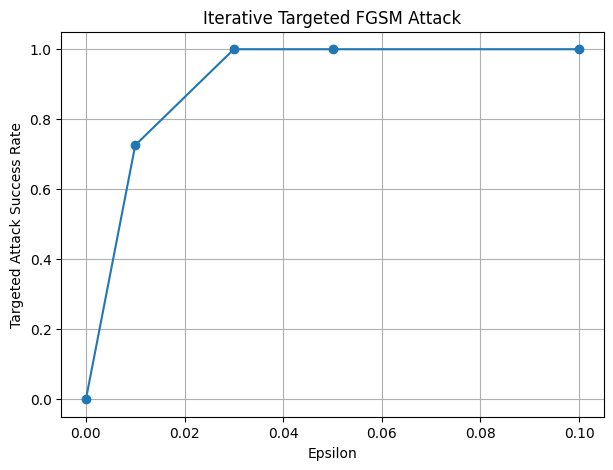

In [40]:
#Iterative targeted FGSM evaluation
epsilons = [0.0, 0.01, 0.03, 0.05, 0.1]

iterative_success_rates = []

alpha = 0.005
num_steps = 10

for epsilon in epsilons:

    images, labels = next(iter(val_loader))

    images = images.to(device)
    labels = labels.to(device)

    target_labels = torch.full_like(
        labels,
        target_class
    )

    with torch.no_grad():
        original_outputs = model(images)

        original_predictions = (
            original_outputs.argmax(dim=1)
        )

    targeted_images = targeted_iterative_fgsm(
        model,
        images,
        target_labels,
        epsilon,
        alpha,
        num_steps
    )

    with torch.no_grad():

        targeted_outputs = model(
            targeted_images
        )

        targeted_predictions = (
            targeted_outputs.argmax(dim=1)
        )

    # Exclude samples already belonging to or predicted as the target class
    mask = (
        (labels != target_class)
        &
        (original_predictions != target_class)
    )

    success_rate = (
        targeted_predictions[mask] == target_class
    ).float().mean().item()

    iterative_success_rates.append(
        success_rate
    )

    print(
        f"Epsilon: {epsilon:.2f} | "
        f"Success rate: {success_rate * 100:.2f}%"
    )


plt.figure(figsize=(7, 5))

plt.plot(
    epsilons,
    iterative_success_rates,
    marker="o"
)

plt.xlabel("Epsilon")
plt.ylabel("Targeted Attack Success Rate")
plt.title("Iterative Targeted FGSM Attack")
plt.grid()
plt.show()

La variante iterativa risulta significativamente più efficace rispetto al targeted FGSM a singolo passo. Il success rate raggiunge infatti il 100% già per ɛ =0.03 e rimane tale per valori superiori. Questo comportamento è dovuto al fatto che il gradiente viene ricalcolato dopo ogni piccolo aggiornamento dell’immagine, correggendo progressivamente la direzione della perturbazione verso la classe target. In questo modo si evita il problema osservato nel FGSM a singolo passo, dove una perturbazione troppo grande lungo un’unica direzione può ridurre l’efficacia dell’attacco.